# Chapter 1. Vectors and vector spaces

In [2]:
from sklearn.datasets import load_iris 
# Use the iris dataset from sklearn.datasets
# https://en.wikipedia.org/wiki/Iris_flower_data_set

data = load_iris() # Loads the iris dataset

X, y = data["data"], data["target"] 
# X is a 2D array (matrix) of shape (150, 4) representing 150 samples with 4 features each
# y is a 1D array of shape (150,) representing the class labels for each sample
# Each row in X corresponds to a sample, and each column corresponds to a feature
# The features are sepal length, sepal width, petal length, and petal width
# The target variable y contains the class labels (0, 1, or 2) corresponding to the three iris species
# Each class label corresponds to a different iris species:
# 0: Setosa
# 1: Versicolor
# 2: Virginica
# The dataset is commonly used for classification tasks in machine learning
# example of y
# X[:5]  # Show the first 5 samples
# y[:5]  # Show the first 5 labels

In [3]:
# show all datasets of sklearn.datasets
import sklearn.datasets
print([name for name in dir(sklearn.datasets) if not name.startswith("_")])
#provides a list of all available datasets in sklearn.datasets



['clear_data_home', 'data', 'descr', 'dump_svmlight_file', 'fetch_20newsgroups', 'fetch_20newsgroups_vectorized', 'fetch_california_housing', 'fetch_covtype', 'fetch_file', 'fetch_kddcup99', 'fetch_lfw_pairs', 'fetch_lfw_people', 'fetch_olivetti_faces', 'fetch_openml', 'fetch_rcv1', 'fetch_species_distributions', 'get_data_home', 'load_breast_cancer', 'load_diabetes', 'load_digits', 'load_files', 'load_iris', 'load_linnerud', 'load_sample_image', 'load_sample_images', 'load_svmlight_file', 'load_svmlight_files', 'load_wine', 'make_biclusters', 'make_blobs', 'make_checkerboard', 'make_circles', 'make_classification', 'make_friedman1', 'make_friedman2', 'make_friedman3', 'make_gaussian_quantiles', 'make_hastie_10_2', 'make_low_rank_matrix', 'make_moons', 'make_multilabel_classification', 'make_regression', 'make_s_curve', 'make_sparse_coded_signal', 'make_sparse_spd_matrix', 'make_sparse_uncorrelated', 'make_spd_matrix', 'make_swiss_roll', 'textwrap']


In [4]:
# show a short description for every dataset in sklearn.datasets
for name in dir(sklearn.datasets):
    if not name.startswith("_"):
        dataset = getattr(sklearn.datasets, name)
        # Show a short description of the dataset
        desc_src = (dataset.__doc__ or getattr(dataset, "DESCR", None)) or ""
        first_line = next((ln for ln in str(desc_src).strip().splitlines() if ln.strip()), "No description available")
        print(f"{name}: {' '.join(first_line.split())}")
# This provides a brief overview of each dataset available in sklearn.datasets


clear_data_home: Delete all the content of the data home cache.
data: No description available
descr: No description available
dump_svmlight_file: Dump the dataset in svmlight / libsvm file format.
fetch_20newsgroups: Load the filenames and data from the 20 newsgroups dataset (classification).
fetch_20newsgroups_vectorized: Load and vectorize the 20 newsgroups dataset (classification).
fetch_california_housing: Load the California housing dataset (regression).
fetch_covtype: Load the covertype dataset (classification).
fetch_file: Fetch a file from the web if not already present in the local folder.
fetch_kddcup99: Load the kddcup99 dataset (classification).
fetch_lfw_pairs: Load the Labeled Faces in the Wild (LFW) pairs dataset (classification).
fetch_lfw_people: Load the Labeled Faces in the Wild (LFW) people dataset (classification).
fetch_olivetti_faces: Load the Olivetti faces data-set from AT&T (classification).
fetch_openml: Fetch dataset from openml by name or dataset id.
fetch

In [5]:
X[:10] # Show the first 10 samples, [:10] means "from the start up to (but not including) index 10"] 


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [6]:
y[:10]  # Show the first 10 labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
X.shape # Show the shape of the feature matrix # X is a 2D array with shape (150, 4), meaning it has 150 samples and 4 features each
# matrices are 2D arrays (tables)

(150, 4)

In [8]:
y # are the class labels for each sample, corresponding to the three iris species, and are used for supervised learning tasks.
# the class labels are integers representing the species:
# 0: Setosa
# 1: Versicolor
# 2: Virginica
# y is a 1D array with shape (150,) containing the class labels for each sample, i.e. a vector i.e. a list of integers

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
y.shape  # Show the shape of the labels array

(150,)

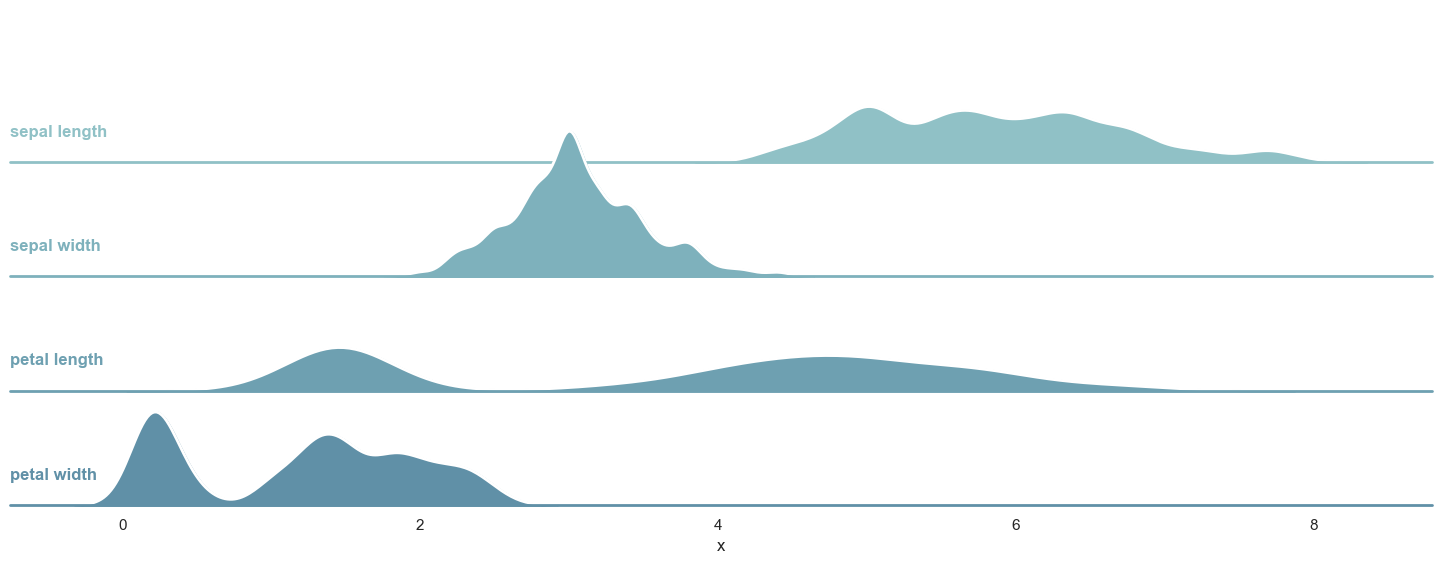

In [10]:
#%pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
# set_theme is used to set the aesthetic style of the plots
# The style is set to "white" with a transparent background for the axes
# rc is a dictionary that allows you to customize various aspects of the plot's appearance
# In this case, it is used to set the background color of the axes to be transparent
# This allows for a cleaner look, especially when overlaying multiple plots
# The transparency helps to focus on the data being presented without distractions from the plot background
# Overall, this approach enhances the visual appeal and clarity of the plots.

# Create the data
x = X.ravel() # Flatten the 2D array into a 1D array
#print(x)
labels = ["sepal length", "sepal width", "petal length", "petal width"]
g = np.tile(labels, len(X)) # Create a 1D array of group labels
#print(g)
# Repeat each label for the number of samples in X
# This creates a label for each feature in each sample
# The resulting array g has the same length as x
# This ensures that each feature is associated with its corresponding label
# Create a DataFrame from the arrays
df = pd.DataFrame(dict(x=x, g=g))

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="g", hue="g", aspect=10, height=1.5, palette=pal)

# Draw the densities
g.map(sns.kdeplot, "x", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add reference line
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Label each plot
g.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold", color=color,
                                             ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
g.figure.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()

In [21]:
X_scaled = (X - X.mean(axis=0))/X.std(axis=0)

In [12]:
X_scaled[:10]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ],
       [-0.53717756,  1.93979142, -1.16971425, -1.05217993],
       [-1.50652052,  0.78880759, -1.34022653, -1.18381211],
       [-1.02184904,  0.78880759, -1.2833891 , -1.3154443 ],
       [-1.74885626, -0.36217625, -1.34022653, -1.3154443 ],
       [-1.14301691,  0.09821729, -1.2833891 , -1.44707648]])

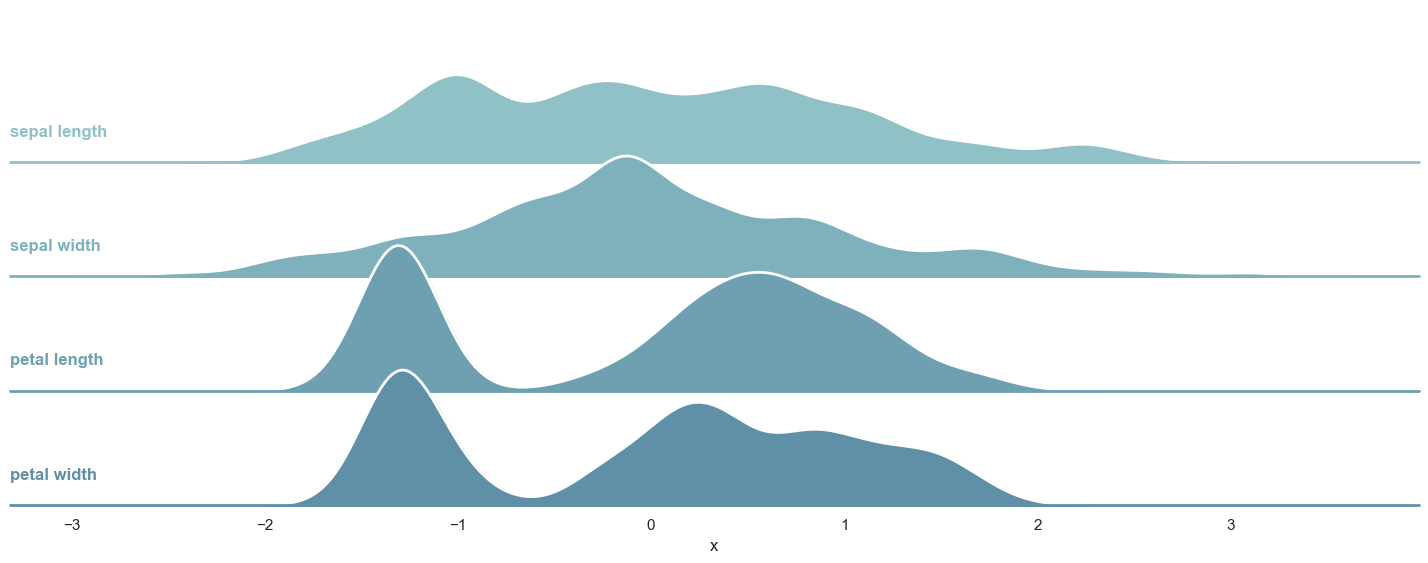

In [13]:
# Create the data
x = X_scaled.ravel()
labels = ["sepal length", "sepal width", "petal length", "petal width"]
g = np.tile(labels, X_scaled.shape[0])
df = pd.DataFrame(dict(x=x, g=g))

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
grid = sns.FacetGrid(df, row="g", hue="g", aspect=10, height=1.5, palette=pal)

# Draw the densities
grid.map(sns.kdeplot, "x", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
grid.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add reference line
grid.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Add labels to each plot
grid.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold", color=color,
                                                ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
grid.figure.subplots_adjust(hspace=-.25)
grid.set_titles("")
grid.set(yticks=[], ylabel="")
grid.despine(bottom=True, left=True)

plt.show()


## Understanding Lambda Functions

Lambda functions are anonymous functions that can be defined inline. They're particularly useful for short, simple operations that don't warrant a full function definition.

In [22]:
# Simple lambda examples

# 1. Basic lambda that squares a number
square = lambda x: x**2
print(f"square(5) = {square(5)}")

# 2. Lambda with multiple parameters  
add = lambda x, y: x + y
print(f"add(3, 4) = {add(3, 4)}")

# 3. Using lambda with built-in functions like map()
numbers = [1, 2, 3, 4, 5]
squared_numbers = list(map(lambda x: x**2, numbers))
print(f"Squared numbers: {squared_numbers}")

# 4. Using lambda with filter()
even_numbers = list(filter(lambda x: x % 2 == 0, numbers))
print(f"Even numbers: {even_numbers}")

# 5. Lambda in a list (similar to how seaborn's map() works)
operations = [
    lambda x: x + 1,    # add 1
    lambda x: x * 2,    # multiply by 2  
    lambda x: x**2      # square
]

value = 3
for i, operation in enumerate(operations):
    result = operation(value)
    print(f"Operation {i+1} on {value}: {result}")

square(5) = 25
add(3, 4) = 7
Squared numbers: [1, 4, 9, 16, 25]
Even numbers: [2, 4]
Operation 1 on 3: 4
Operation 2 on 3: 6
Operation 3 on 3: 9


In [23]:
# Lambda vs Regular Function Comparison

# Traditional function definition
def multiply_traditional(x, y):
    return x * y

# Equivalent lambda function
multiply_lambda = lambda x, y: x * y

# Both work identically
print(f"Traditional function: multiply_traditional(6, 7) = {multiply_traditional(6, 7)}")
print(f"Lambda function: multiply_lambda(6, 7) = {multiply_lambda(6, 7)}")

# The power of lambda: inline usage without naming
# This is exactly how seaborn's map() uses lambdas!
data = [1, 2, 3, 4, 5]
transformed = list(map(lambda x: x * 2 + 1, data))
print(f"Transformed data: {transformed}")

# Lambda with multiple arguments (like in the ridge plot)
def apply_function_with_context(func, value, context_info):
    """Simulates how seaborn passes data, color, and label to lambda"""
    return func(value, context_info, f"Label for {value}")

# This mimics the structure used in the ridge plot
result = apply_function_with_context(
    lambda data, color, label: f"Processing {data} with {color} color and '{label}'",
    42, 
    "blue"
)
print(f"Ridge plot style lambda result: {result}")

Traditional function: multiply_traditional(6, 7) = 42
Lambda function: multiply_lambda(6, 7) = 42
Transformed data: [3, 5, 7, 9, 11]
Ridge plot style lambda result: Processing 42 with blue color and 'Label for 42'


## Vectors in practice

### Tuples

In [14]:
v_tuple = (1, 3.5, -2.71, "a string", 42)

In [15]:
v_tuple

(1, 3.5, -2.71, 'a string', 42)

In [16]:
type(v_tuple)

tuple

In [17]:
v_tuple[0]

1

In [18]:
len(v_tuple)

5

In [19]:
v_tuple[1:4]

(3.5, -2.71, 'a string')

In [20]:
v_tuple[0] = 2

TypeError: 'tuple' object does not support item assignment

### Lists

In [24]:
v_list = [1, 3.5, -2.71, "qwerty"]

In [25]:
type(v_list)

list

In [26]:
v_list[0] = "this is a string"

In [27]:
v_list

['this is a string', 3.5, -2.71, 'qwerty']

In [ ]:
v_list_addr = id(v_list) # Get the memory address of v_list

In [29]:
v_list_addr

4756858880

In [30]:
v_list.append([42])    # adding the list [42] to the end of our list
v_list

['this is a string', 3.5, -2.71, 'qwerty', [42]]

In [31]:
id(v_list) == v_list_addr    # adding elements doesn't create any new objects

True

In [32]:
v_list.pop(1)    # removing the element at the index "1"
v_list

['this is a string', -2.71, 'qwerty', [42]]

In [ ]:
id(v_list) == v_list_addr    # removing elements still doesn't create any new objects

In [33]:
[1, 2, 3] + [4, 5, 6]

[1, 2, 3, 4, 5, 6]

In [34]:
3*[1, 2, 3]

[1, 2, 3, 1, 2, 3, 1, 2, 3]

### NumPy arrays

In [35]:
l = [2**142 + 1, "a string"]

In [ ]:
l.append(lambda x: x) # Identity function
# This function returns its input unchanged
# It can be useful as a default or placeholder function
# It can also be used in higher-order functions that require a callable


In [38]:
l

[5575186299632655785383929568162090376495105,
 'a string',
 <function __main__.<lambda>(x)>]

In [39]:
[id(x) for x in l]

[4745151856, 4737075888, 4744052544]

In [40]:
import numpy as np

In [41]:
X = np.array([87.7, 4.5, -4.1, 42.1414, -3.14, 2.001])    # creating a NumPy array from a Python list

In [42]:
X

array([87.7   ,  4.5   , -4.1   , 42.1414, -3.14  ,  2.001 ])

In [43]:
np.ones(shape=7)    # initializing a NumPy array from scratch using ones

array([1., 1., 1., 1., 1., 1., 1.])

In [44]:
np.zeros(shape=5)    # initializing a NumPy array from scratch using zeros

array([0., 0., 0., 0., 0.])

In [45]:
np.random.rand(10)

array([0.14182311, 0.14423016, 0.93590415, 0.60859511, 0.78019898,
       0.15019546, 0.39377834, 0.08754691, 0.29126747, 0.55197667])

In [46]:
np.zeros_like(X)

array([0., 0., 0., 0., 0., 0.])

In [47]:
X[0] = 1545.215
X

array([1545.215 ,    4.5   ,   -4.1   ,   42.1414,   -3.14  ,    2.001 ])

In [48]:
X[1:4]

array([ 4.5   , -4.1   , 42.1414])

In [49]:
X[0] = "str"

ValueError: could not convert string to float: 'str'

In [50]:
X.dtype

dtype('float64')

In [51]:
val = 23
type(val)

int

In [52]:
X[0] = val
X

array([23.    ,  4.5   , -4.1   , 42.1414, -3.14  ,  2.001 ])

In [53]:
for x in X:
    print(x)

23.0
4.5
-4.1
42.1414
-3.14
2.001


### NumPy arrays as vectors

In [54]:
v_1 = np.array([-4.0, 1.0, 2.3])
v_2 = np.array([-8.3, -9.6, -7.7])

In [55]:
v_1 + v_2    # adding v_1 and v_2 together as vectors

array([-12.3,  -8.6,  -5.4])

In [56]:
10.0*v_1    # multiplying v_1 with a scalar

array([-40.,  10.,  23.])

In [57]:
v_1 * v_2    # the elementwise product of v_1 and v_2

array([ 33.2 ,  -9.6 , -17.71])

In [58]:
np.zeros(shape=3) + 1

array([1., 1., 1.])

In [59]:
def f(x):
    return 3*x**2 - x**4

In [60]:
f(v_1)

array([-208.    ,    2.    ,  -12.1141])

In [ ]:
from timeit import timeit


n_runs = 100000
size = 1000


t_add_builtin = timeit(
    "[x + y for x, y in zip(v_1, v_2)]",
    setup=f"size={size}; v_1 = [0 for _ in range(size)]; v_2 = [0 for _ in range(size)]",
    number=n_runs
)

t_add_numpy = timeit(
    "v_1 + v_2",
    setup=f"import numpy as np; size={size}; v_1 = np.zeros(shape=size); v_2 = np.zeros(shape=size)",
    number=n_runs
)


print(f"Built-in addition:       \t{t_add_builtin} s")
print(f"NumPy addition:          \t{t_add_numpy} s")
print(f"Performance improvement: \t{t_add_builtin/t_add_numpy:.3f} times faster") # Comment explaining the performance improvement
# NumPy is significantly faster than the built-in approach due to its optimized implementation and use of contiguous memory.
# This allows NumPy to leverage low-level optimizations and perform operations in bulk, reducing overhead.

Built-in addition:       	2.7591136660194024 s
NumPy addition:          	0.0351803750381805 s
Performance improvement: 	78.428 times faster


### Is NumPy really faster than Python?

In [62]:
from numpy.random import random as random_np
from random import random as random_py


n_runs = 10000000
t_builtin = timeit(random_py, number=n_runs)
t_numpy = timeit(random_np, number=n_runs)

print(f"Built-in random:\t{t_builtin} s")
print(f"NumPy random:   \t{t_numpy} s")

Built-in random:	0.17115241597639397 s
NumPy random:   	1.008308833988849 s


In [63]:
size = 1000
n_runs = 10000

t_builtin_list = timeit(
    "[random_py() for _ in range(size)]",
    setup=f"from random import random as random_py; size={size}",
    number=n_runs
)

t_numpy_array = timeit(
    "random_np(size)",
    setup=f"from numpy.random import random as random_np; size={size}",
    number=n_runs
)

print(f"Built-in random with lists:\t{t_builtin_list}s")
print(f"NumPy random with arrays:  \t{t_numpy_array}s")

Built-in random with lists:	0.2471875000046566s
NumPy random with arrays:  	0.021881291992031038s


In [64]:
from IPython.core import page
page.page = print

In [65]:
def builtin_random_single(n_runs):
    for _ in range(n_runs):
        random_py()

In [66]:
n_runs = 10000000

%prun builtin_random_single(n_runs)

         10000004 function calls in 0.608 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.377    0.377    0.608    0.608 2471337341.py:1(builtin_random_single)
 10000000    0.232    0.000    0.232    0.000 {method 'random' of '_random.Random' objects}
        1    0.000    0.000    0.608    0.608 {built-in method builtins.exec}
        1    0.000    0.000    0.608    0.608 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
 

In [68]:
def numpy_random_single(n_runs):
    for _ in range(n_runs):
        random_np()

In [69]:
%prun numpy_random_single(n_runs)

         4 function calls in 1.231 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    1.231    1.231    1.231    1.231 2015715881.py:1(numpy_random_single)
        1    0.000    0.000    1.231    1.231 {built-in method builtins.exec}
        1    0.000    0.000    1.231    1.231 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
 

In [70]:
def builtin_random_list(size, n_runs):
    for _ in range(n_runs):
        [random_py() for _ in range(size)]

In [71]:
size = 1000
n_runs = 10000

%prun builtin_random_list(size, n_runs)

         10010004 function calls in 0.657 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    10000    0.386    0.000    0.628    0.000 2575888617.py:3(<listcomp>)
 10000000    0.242    0.000    0.242    0.000 {method 'random' of '_random.Random' objects}
        1    0.029    0.029    0.657    0.657 2575888617.py:1(builtin_random_list)
        1    0.000    0.000    0.657    0.657 {built-in method builtins.exec}
        1    0.000    0.000    0.657    0.657 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
 

In [72]:
def numpy_random_array(size, n_runs):
    for _ in range(n_runs):
        random_np(size)

In [73]:
%prun numpy_random_array(size, n_runs)

         4 function calls in 0.032 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.032    0.032    0.032    0.032 1681905588.py:1(numpy_random_array)
        1    0.000    0.000    0.032    0.032 {built-in method builtins.exec}
        1    0.000    0.000    0.032    0.032 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
 

In [74]:
sizes = list(range(1, 100))

runtime_builtin = [
    timeit(
        "[random_py() for _ in range(size)]",
        setup=f"from random import random as random_py; size={size}",
        number=100000
    )
    for size in sizes
]


runtime_numpy = [
    timeit(
        "random_np(size)",
        setup=f"from numpy.random import random as random_np; size={size}",
        number=100000
    )
    for size in sizes
]

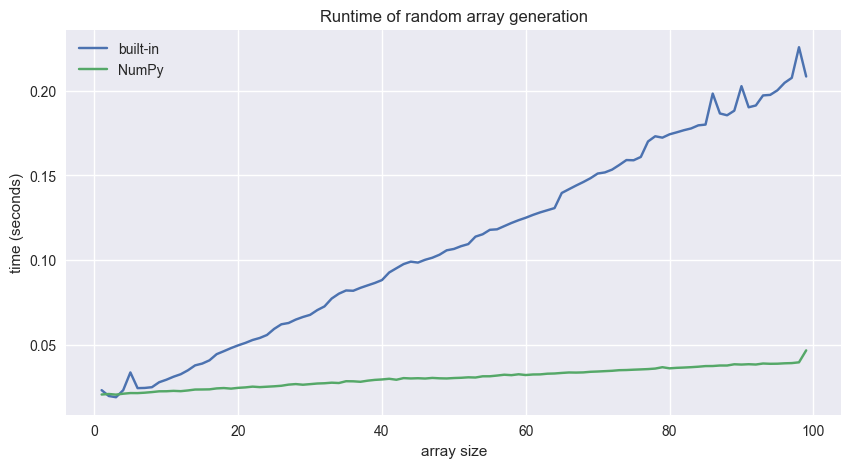

In [75]:
import matplotlib.pyplot as plt


with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10, 5))
    plt.plot(sizes, runtime_builtin, label="built-in")
    plt.plot(sizes, runtime_numpy, label="NumPy")
    plt.xlabel("array size")
    plt.ylabel("time (seconds)")
    plt.title("Runtime of random array generation")
    plt.legend()
    plt.show()